In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

In [2]:
# ==================== ПАРАМЕТРЫ ====================
sigma = 1.0
a, b = 0.0, 6.0
M = rayleigh.pdf(1.0, scale=sigma)

# Теоретические характеристики
mu_theor = sigma * np.sqrt(np.pi / 2)
var_theor = sigma**2 * (4 - np.pi) / 2
std_theor = np.sqrt(var_theor)

print(f'Максимум плотности M = {M:.5f}')
print(f'Теоретические значения:')
print(f'   M(X)  = {mu_theor:.4f}')
print(f'   D(X)  = {var_theor:.4f}')
print(f'   std(X)= {std_theor:.4f}\n')

Максимум плотности M = 0.60653
Теоретические значения:
   M(X)  = 1.2533
   D(X)  = 0.4292
   std(X)= 0.6551



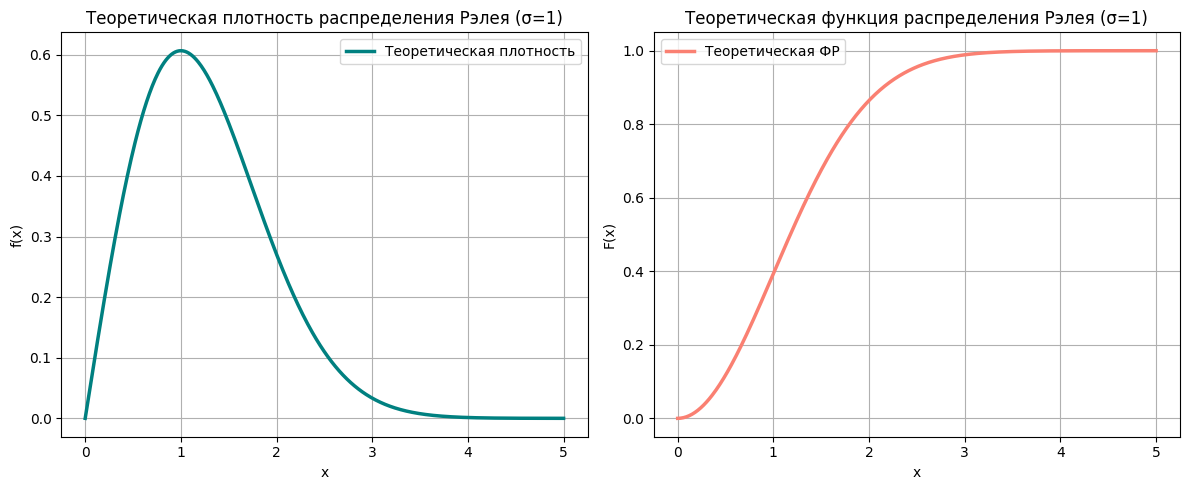

In [3]:
# ==================== ТЕОРЕТИЧЕСКИЕ ГРАФИКИ ====================
x_theor = np.linspace(0, 5, 500)
pdf_theor = rayleigh.pdf(x_theor, scale=sigma)
cdf_theor = rayleigh.cdf(x_theor, scale=sigma)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_theor, pdf_theor, color='teal', linewidth=2.5, label='Теоретическая плотность')
plt.title('Теоретическая плотность распределения Рэлея (σ=1)')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_theor, cdf_theor, color='salmon', linewidth=2.5, label='Теоретическая ФР')
plt.title('Теоретическая функция распределения Рэлея (σ=1)')
plt.xlabel('x'); plt.ylabel('F(x)'); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

In [4]:
# ==================== ФУНКЦИЯ ГЕНЕРАЦИИ ====================
def generate_rayleigh_rejection(N, sigma=1.0, a=0.0, b=6.0):
    M = rayleigh.pdf(1.0, scale=sigma)
    X = []
    counter = 0
    while len(X) < N:
        y = np.random.uniform(a, b)
        z = np.random.uniform(0, M)
        if z <= (y / sigma**2) * np.exp(-y**2 / (2 * sigma**2)):
            X.append(y)
        counter += 1
    return np.array(X), counter - N

In [5]:
# ==================== ГЕНЕРАЦИЯ ТРЁХ ВЫБОРОК ====================
np.random.seed(42)
Ns = [1000, 5000, 10000]
samples = {}
rejects = {}

print('Генерация выборок методом исключения...')
for N in Ns:
    X, rejected = generate_rayleigh_rejection(N)
    samples[N] = X
    rejects[N] = rejected
    
    mean_sample = np.mean(X)
    var_sample = np.var(X, ddof=1)
    std_sample = np.std(X, ddof=1)
    
    print(f'N = {N:5d} | '
          f'среднее = {mean_sample:.4f} | '
          f'дисперсия = {var_sample:.4f} | '
          f'СКО = {std_sample:.4f} | '
          f'отброшено = {rejected}')

Генерация выборок методом исключения...
N =  1000 | среднее = 1.2242 | дисперсия = 0.4063 | СКО = 0.6374 | отброшено = 2483
N =  5000 | среднее = 1.2594 | дисперсия = 0.4214 | СКО = 0.6492 | отброшено = 13354
N = 10000 | среднее = 1.2456 | дисперсия = 0.4203 | СКО = 0.6483 | отброшено = 26327


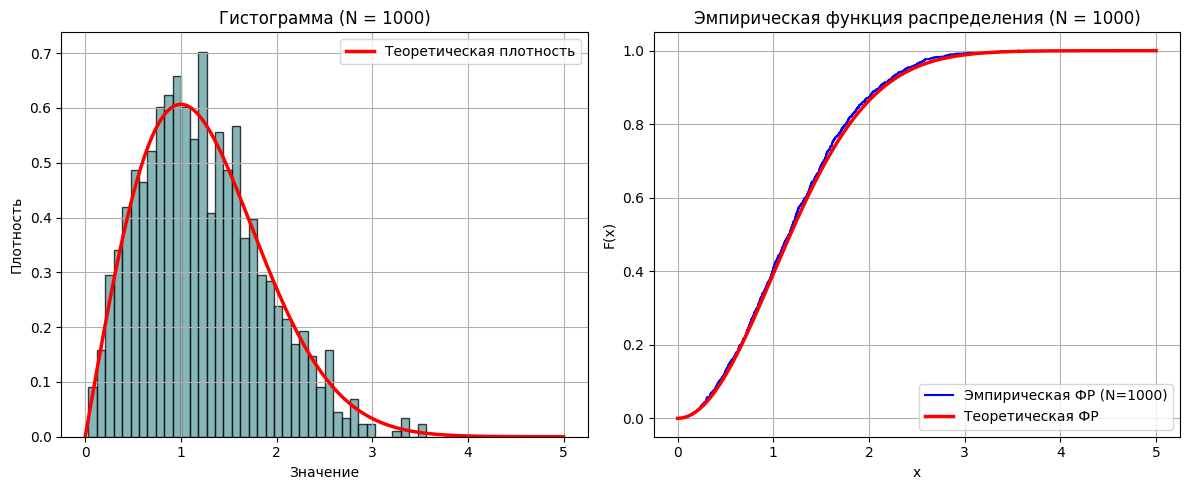

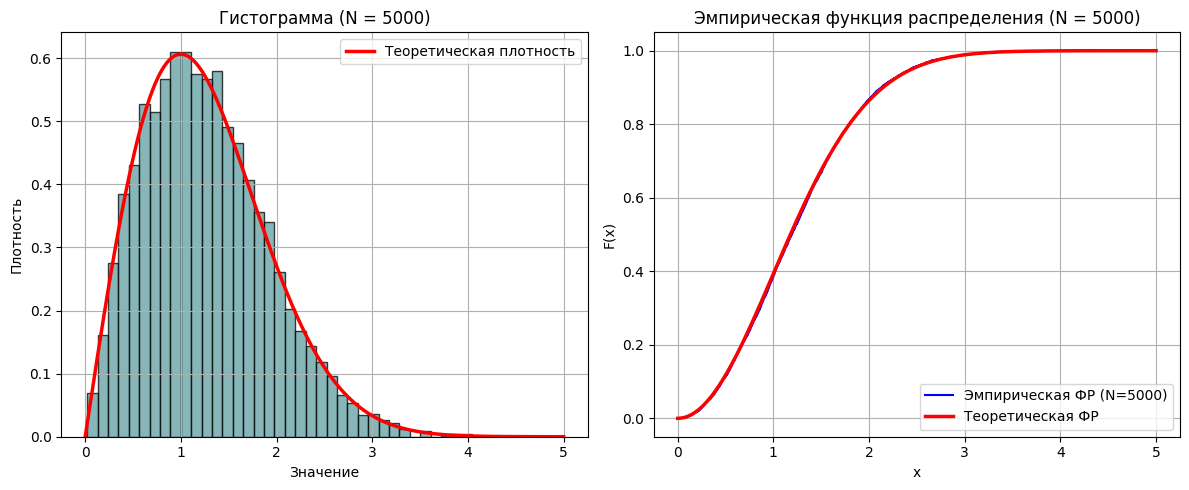

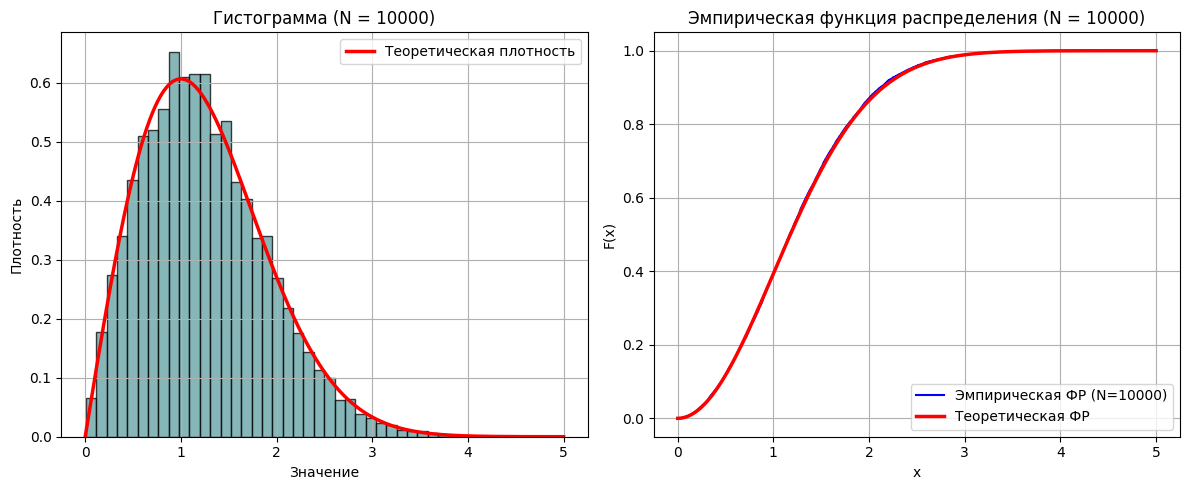

In [6]:
# ==================== ГИСТОГРАММЫ И ЭМПИРИЧЕСКИЕ ФР ====================
for N in Ns:
    X = samples[N]
    
    plt.figure(figsize=(12, 5))
    
    # Гистограмма
    plt.subplot(1, 2, 1)
    plt.hist(X, bins=40, density=True, alpha=0.75, color='cadetblue', edgecolor='black')
    plt.plot(x_theor, pdf_theor, 'r-', linewidth=2.5, label='Теоретическая плотность')
    plt.title(f'Гистограмма (N = {N})')
    plt.xlabel('Значение'); plt.ylabel('Плотность'); plt.grid(True); plt.legend()
    
    # Эмпирическая функция распределения
    plt.subplot(1, 2, 2)
    sorted_X = np.sort(X)
    ecdf = np.arange(1, len(sorted_X) + 1) / len(sorted_X)
    plt.step(sorted_X, ecdf, where='post', color='blue', linewidth=1.5, label=f'Эмпирическая ФР (N={N})')
    plt.plot(x_theor, cdf_theor, 'r-', linewidth=2.5, label='Теоретическая ФР')
    plt.title(f'Эмпирическая функция распределения (N = {N})')
    plt.xlabel('x'); plt.ylabel('F(x)'); plt.grid(True); plt.legend()
    
    plt.tight_layout()
    plt.show()

Построение теста «Распределение на плоскости» (X_i vs X_{i+1})...
Построение теста «Распределение на плоскости» (X_i vs X_{i+1})...


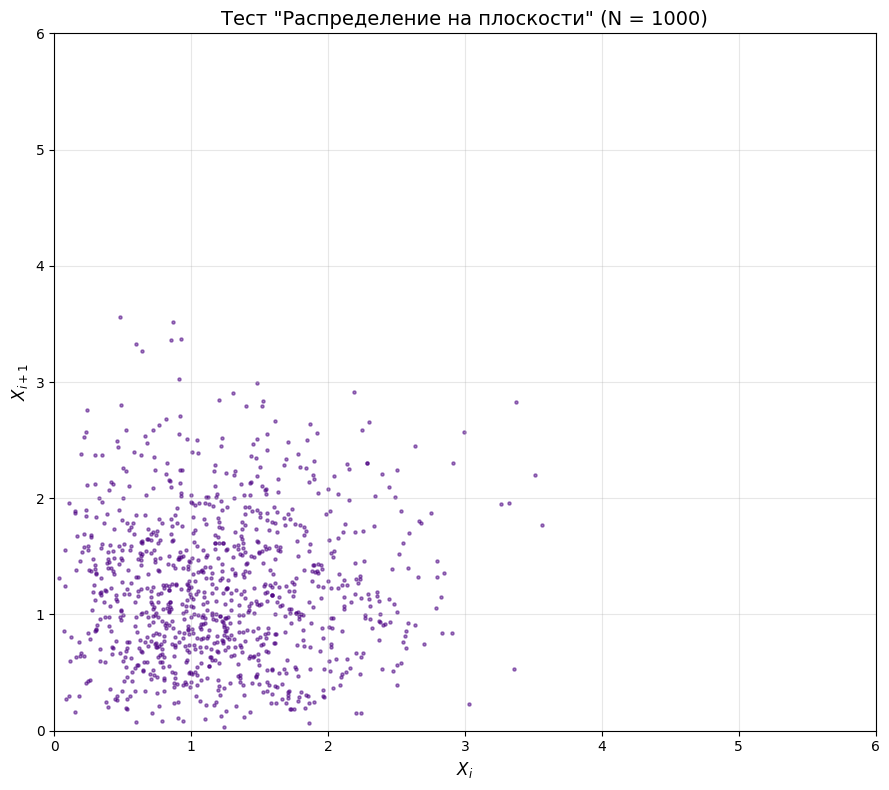

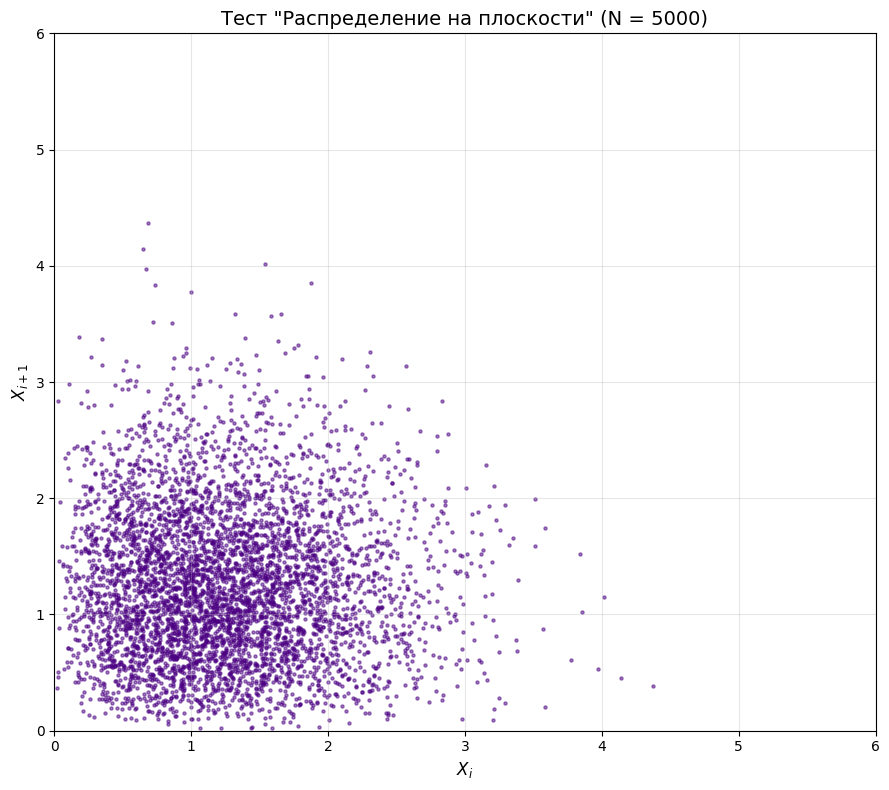

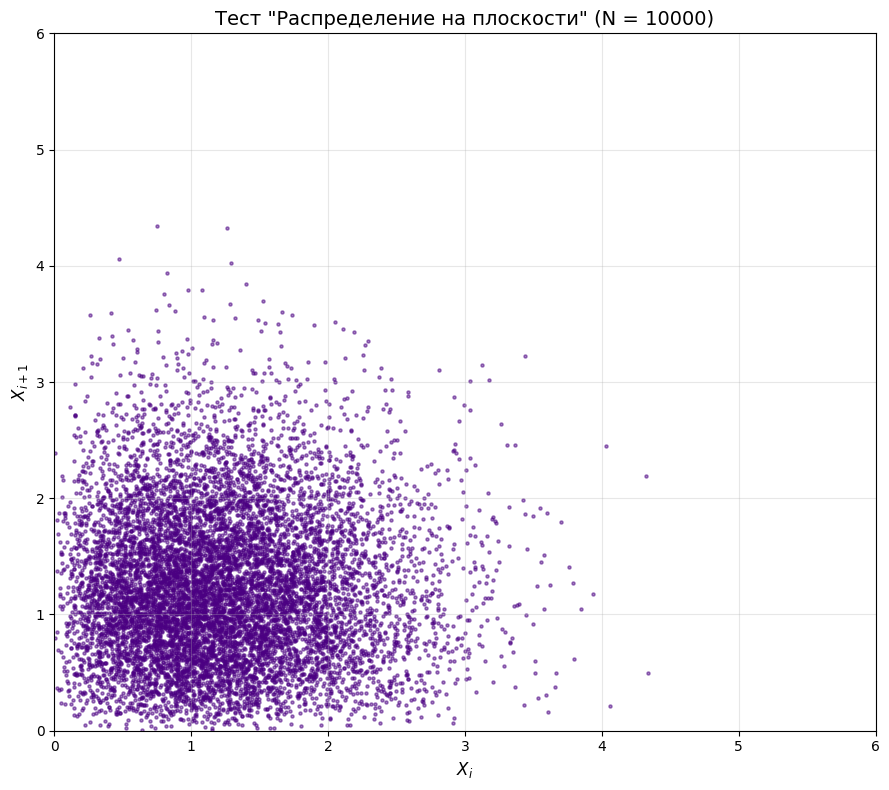

In [10]:
print("Построение теста «Распределение на плоскости» (X_i vs X_{i+1})...")

print("Построение теста «Распределение на плоскости» (X_i vs X_{i+1})...")

for N in [1000, 5000, 10000]:
    X = samples[N]
    xi = X[:-1]      # X_i
    xi1 = X[1:]      # X_{i+1}
    
    plt.figure(figsize=(9, 8))
    plt.scatter(xi, xi1, s=5, alpha=0.5, color='indigo')
    
    plt.title(f'Тест "Распределение на плоскости" (N = {N})', fontsize=14)
    plt.xlabel('$X_i$', fontsize=12)
    plt.ylabel('$X_{i+1}$', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 6)
    plt.ylim(0, 6)
    plt.tight_layout()
    plt.show()